<a href="https://colab.research.google.com/github/Aastha210/DL_MSE1_Case_Studies/blob/main/DL_MSE1_Case_Studies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **CASE STUDY 1: MNIST Digit Recognition	(Data loading & preprocessing	Model design (MLP/CNN)	Training accuracy	Explanation & interpretation)**

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# 🔹 1. Load Data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 🔹 2. Preprocessing
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 🔹 3. Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 🔹 4. CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# 🔹 5. Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 6. Train
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# 🔹 7. Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("CNN Accuracy:", acc)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9327 - loss: 0.2220 - val_accuracy: 0.9794 - val_loss: 0.0609
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9757 - loss: 0.0824 - val_accuracy: 0.9889 - val_loss: 0.0357
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9812 - loss: 0.0626 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9852 - loss: 0.0496 - val_accuracy: 0.9901 - val_loss: 0.0315
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9870 - loss: 0.0428 - val_accuracy: 0.9899 - val_loss: 0.0323
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0323
CNN Accuracy: 0.9898999929428101


In [2]:
import numpy as np

predictions = model.predict(x_test)

pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step



🔹 Sample Predictions


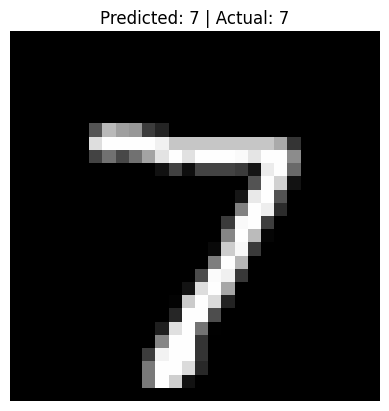

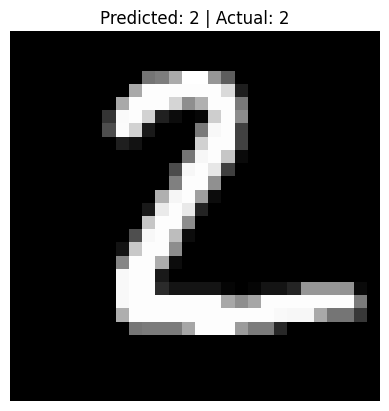

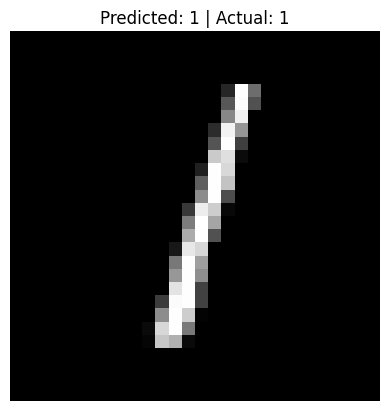

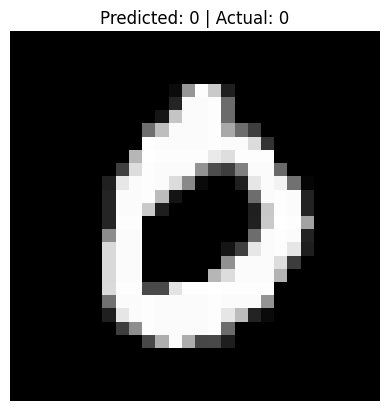

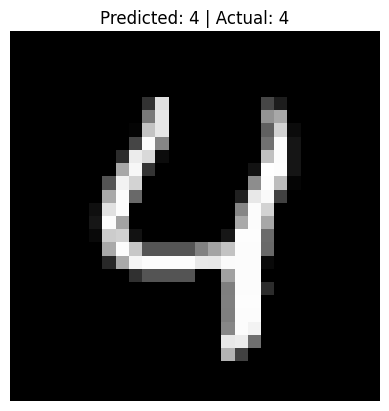

In [3]:
import matplotlib.pyplot as plt

print("\n🔹 Sample Predictions")
for i in range(5):
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]} | Actual: {true_labels[i]}")
    plt.axis('off')
    plt.show()


✅ Correct Predictions


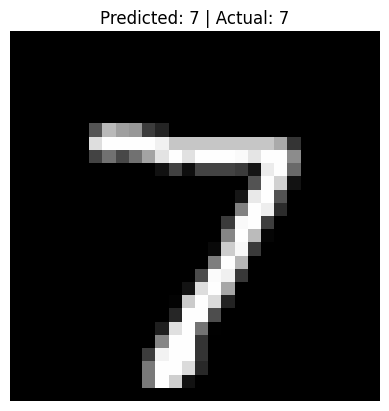

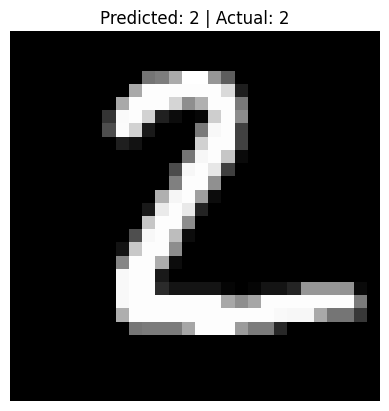

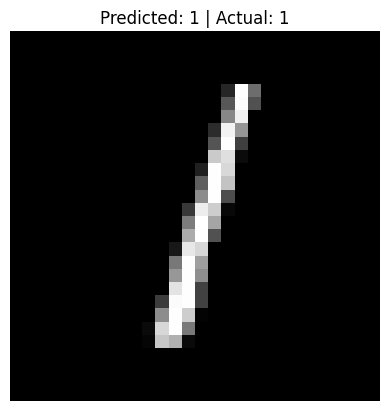


❌ Wrong Predictions


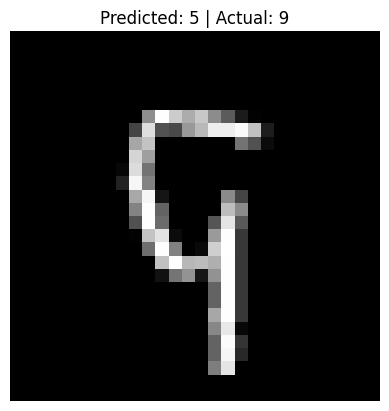

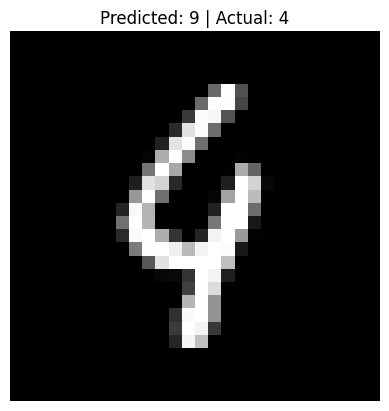

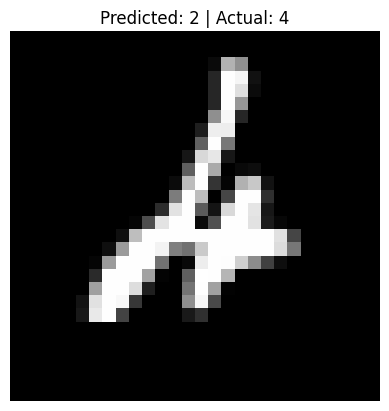

In [4]:
correct = []
wrong = []

for i in range(len(pred_labels)):
    if pred_labels[i] == true_labels[i] and len(correct) < 3:
        correct.append(i)
    elif pred_labels[i] != true_labels[i] and len(wrong) < 3:
        wrong.append(i)

print("\n✅ Correct Predictions")
for i in correct:
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]} | Actual: {true_labels[i]}")
    plt.axis('off')
    plt.show()

print("\n❌ Wrong Predictions")
for i in wrong:
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Predicted: {pred_labels[i]} | Actual: {true_labels[i]}")
    plt.axis('off')
    plt.show()

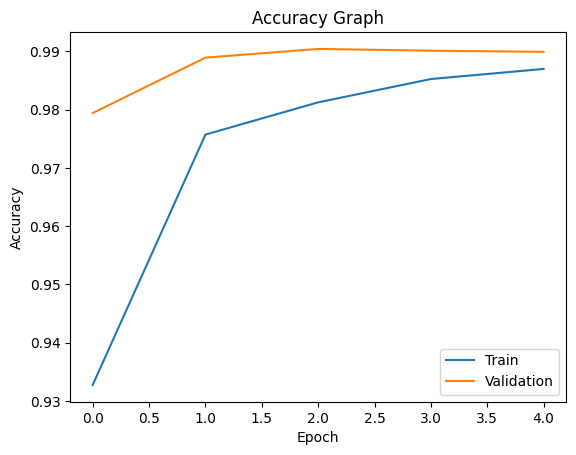

In [5]:
history = model.history

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

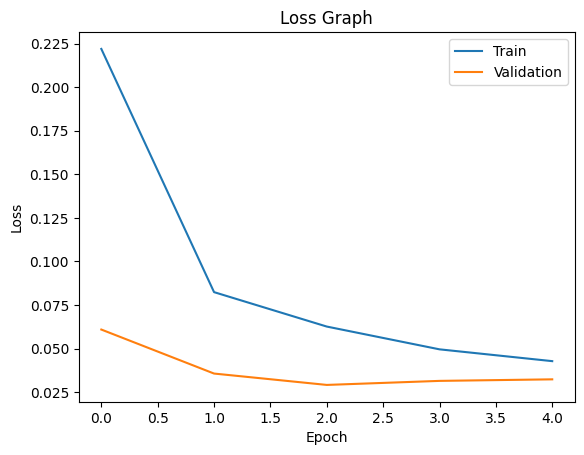

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

### **CASE STUDY 2: CIFAR-10 CNN Classification(Data handling & preprocessing	CNN architecture design	Training performance	Result explanation)**

In [7]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# ==============================
# 2. LOAD DATA
# ==============================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# ==============================
# 3. PREPROCESSING
# ==============================
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Class labels (IMPORTANT for display)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ==============================
# 4. CNN MODEL
# ==============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# ==============================
# 5. COMPILE
# ==============================
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ==============================
# 6. TRAIN
# ==============================
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# ==============================
# 7. EVALUATE
# ==============================
loss, acc = model.evaluate(x_test, y_test)
print("CIFAR-10 Accuracy:", acc)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.3976 - loss: 1.6399 - val_accuracy: 0.5420 - val_loss: 1.2876
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5527 - loss: 1.2648 - val_accuracy: 0.5642 - val_loss: 1.2023
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6070 - loss: 1.1139 - val_accuracy: 0.6480 - val_loss: 0.9985
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6483 - loss: 1.0033 - val_accuracy: 0.6677 - val_loss: 0.9361
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6775 - loss: 0.9269 - val_accuracy: 0.6839 - val_loss: 0.8995
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7000 - loss: 0.8612 - val_accuracy: 0.6987 - val_loss: 0.8644
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7192 - loss: 0.8085 - val_accuracy: 0.7008 - val_loss: 0.8678
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

🔹 Sample Predictions


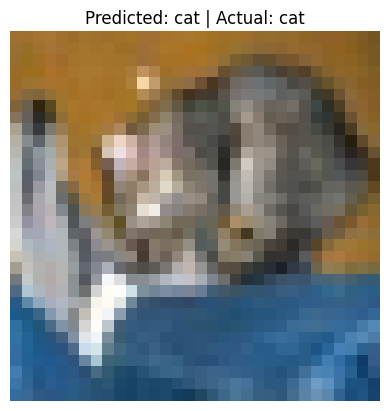

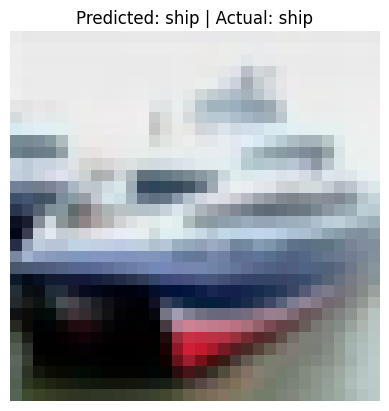

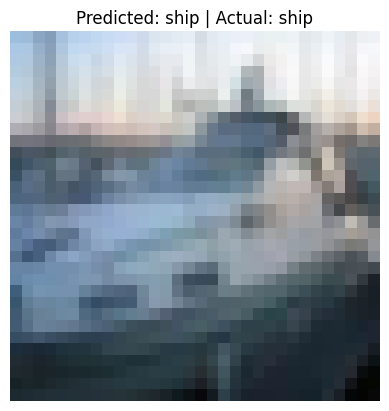

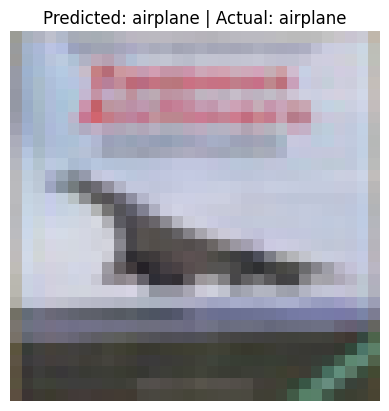

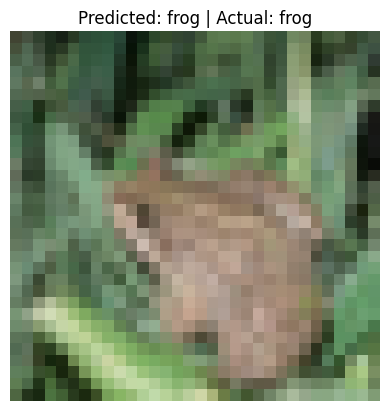

In [8]:
# ==============================
# 8. PREDICTIONS
# ==============================
predictions = model.predict(x_test)

pred_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)
# ==============================
# 9. SHOW SAMPLE PREDICTIONS
# ==============================
print("\n🔹 Sample Predictions")
for i in range(5):
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[pred_labels[i]]} | Actual: {class_names[true_labels[i]]}")
    plt.axis('off')
    plt.show()



✅ Correct Predictions


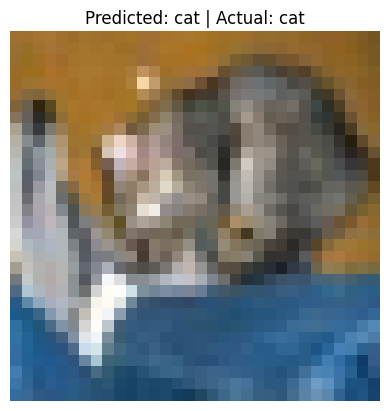

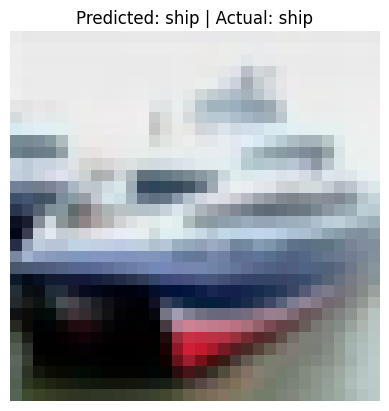

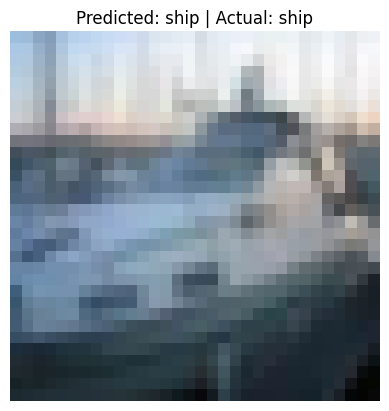


❌ Wrong Predictions


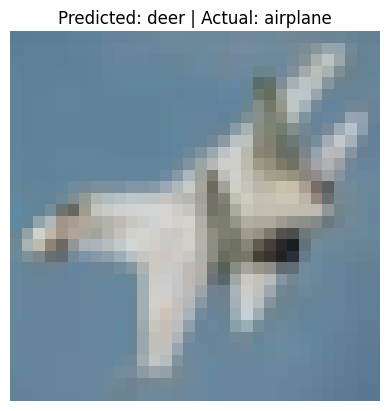

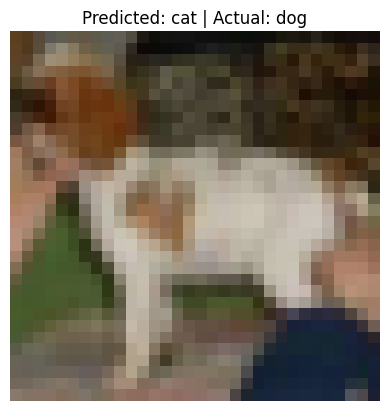

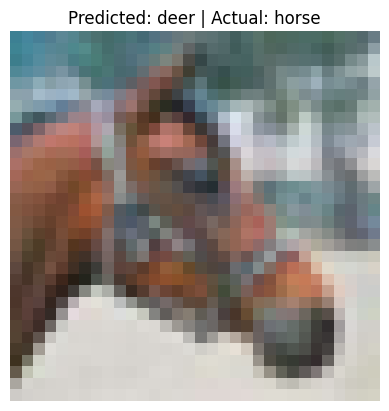

In [9]:
# ==============================
# 10. CORRECT vs WRONG CASES
# ==============================
correct = []
wrong = []

for i in range(len(pred_labels)):
    if pred_labels[i] == true_labels[i] and len(correct) < 3:
        correct.append(i)
    elif pred_labels[i] != true_labels[i] and len(wrong) < 3:
        wrong.append(i)

print("\n✅ Correct Predictions")
for i in correct:
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[pred_labels[i]]} | Actual: {class_names[true_labels[i]]}")
    plt.axis('off')
    plt.show()

print("\n❌ Wrong Predictions")
for i in wrong:
    plt.imshow(x_test[i])
    plt.title(f"Predicted: {class_names[pred_labels[i]]} | Actual: {class_names[true_labels[i]]}")
    plt.axis('off')
    plt.show()

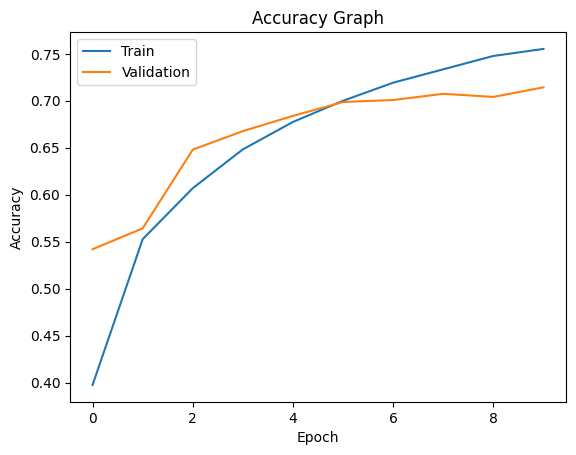

In [10]:
# ==============================
# 11. ACCURACY GRAPH
# ==============================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

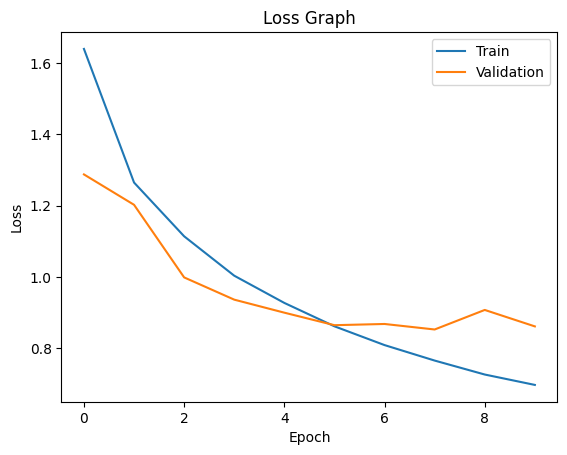

In [11]:
# ==============================
# 12. LOSS GRAPH
# ==============================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

### **CASE STUDY 3: Brain Tumor Detection + CAM(CNN model implementation	Filter & CAM visualization	Localization quality	Medical interpretation)**

In [12]:
from google.colab import files

print("📂 Please select your ZIP dataset file")
uploaded = files.upload()

📂 Please select your ZIP dataset file


Saving archive (1).zip to archive (1).zip


In [13]:
zip_file = list(uploaded.keys())[0]
print("Selected ZIP file:", zip_file)

Selected ZIP file: archive (1).zip


In [14]:
import zipfile
import os

extract_path = "dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted contents:", os.listdir(extract_path))

Extracted contents: ['brain-tumor-mri-dataset']


In [15]:
# Check structure
for root, dirs, files in os.walk("dataset"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-"*40)

Folder: dataset
Subfolders: ['brain-tumor-mri-dataset']
Files: 0
----------------------------------------
Folder: dataset/brain-tumor-mri-dataset
Subfolders: ['notumor', 'glioma', 'pituitary', 'meningioma']
Files: 0
----------------------------------------
Folder: dataset/brain-tumor-mri-dataset/notumor
Subfolders: []
Files: 2000
----------------------------------------
Folder: dataset/brain-tumor-mri-dataset/glioma
Subfolders: []
Files: 1621
----------------------------------------
Folder: dataset/brain-tumor-mri-dataset/pituitary
Subfolders: []
Files: 1757
----------------------------------------
Folder: dataset/brain-tumor-mri-dataset/meningioma
Subfolders: []
Files: 1775
----------------------------------------


In [16]:
# Try to auto-detect inner folder
folders = os.listdir("dataset")

if len(folders) == 1:
    DATASET_PATH = os.path.join("dataset", folders[0])
else:
    DATASET_PATH = "dataset"

print("Using dataset path:", DATASET_PATH)

Using dataset path: dataset/brain-tumor-mri-dataset


In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

print("Classes:", train_data.class_indices)

Found 5723 images belonging to 4 classes.
Found 1430 images belonging to 4 classes.
Classes: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [18]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 133s 410ms/step - accuracy: 0.2520 - loss: -3947.5757 - val_accuracy: 0.2483 - val_loss: -19685.8809
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.2481 - loss: -32487.5508 - val_accuracy: 0.2483 - val_loss: -99.5660
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.2481 - loss: -102922.1328 - val_accuracy: 0.2483 - val_loss: -124047.3438
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.2481 - loss: -224866.0938 - val_accuracy: 0.2483 - val_loss: -251971.8281
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step - accuracy: 0.2481 - loss: -406905.6250 - val_accuracy: 0.2483 - val_loss: -317.5547


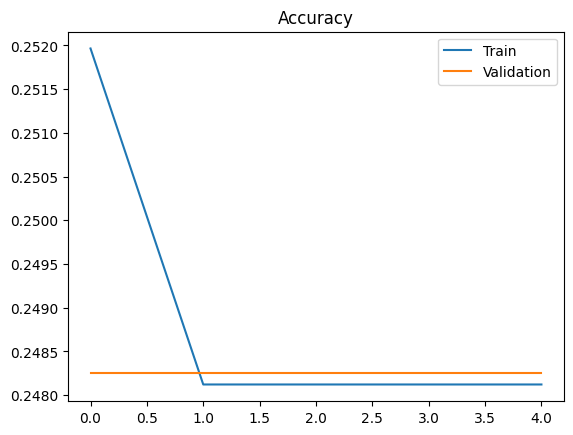

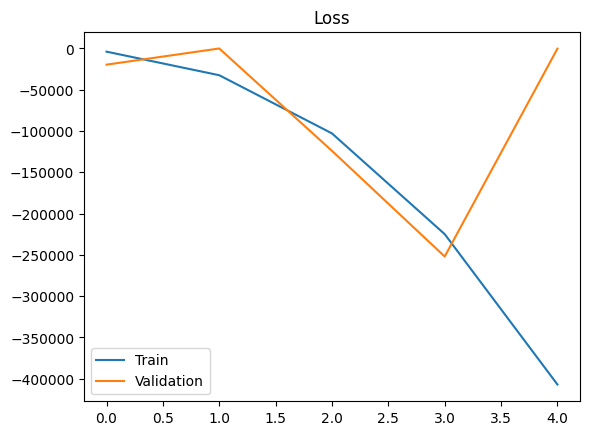

In [21]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [22]:
from google.colab import files
uploaded_img = files.upload()

img_path = list(uploaded_img.keys())[0]
print("Selected image:", img_path)

Saving image 1.webp to image 1.webp
Selected image: image 1.webp


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


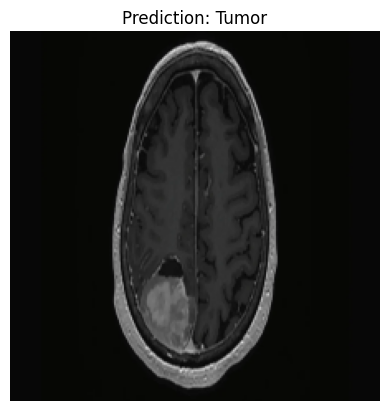

In [23]:
import cv2
import numpy as np

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))

img_array = np.expand_dims(img/255.0, axis=0)

prediction = model.predict(img_array)

label = "Tumor" if prediction[0][0] > 0.5 else "No Tumor"

import matplotlib.pyplot as plt
plt.imshow(img)
plt.title(f"Prediction: {label}")
plt.axis('off')
plt.show()